In [3]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [5]:
 #1A. PROBABILITY BY SIMULATION
 import numpy as np
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4 = (rolls > 4).mean()

print("P(even) ~", round(p_even, 3), "(true 0.5)")
print("P(>4)   ~", round(p_gt4, 3), "(true 0.333)")


P(even) ~ 0.499 (true 0.5)
P(>4)   ~ 0.334 (true 0.333)


In [6]:
# 🔹 1B. THE ADDITION RULE (disjoint events)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [7]:
#lab-1 exercise
import numpy as np
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = (heads == 2).mean()
print("P(both heads) ~", round(p_both_heads, 3))
p_at_least_one = (heads >= 1).mean()
print("P(at least one head) ~", round(p_at_least_one, 3))
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()

total = p_0 + p_1 + p_2

print("P(0) =", round(p_0, 3))
print("P(1) =", round(p_1, 3))
print("P(2) =", round(p_2, 3))
print("P(0) + P(1) + P(2) =", round(total, 3))


P(both heads) ~ 0.249
P(at least one head) ~ 0.75
P(0) = 0.25
P(1) = 0.501
P(2) = 0.249
P(0) + P(1) + P(2) = 1.0


In [8]:
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.333  (true 1/3)


In [9]:
# 🔹 2B. TESTING FOR INDEPENDENCE
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.501
P(A | B)  = 0.667
Independent? False


In [10]:
# lab exercise-2
import numpy as np
rolls = np.random.randint(1, 7, size=100_000)
condition = rolls < 4
p_odd_given_lt4 = (rolls[condition] % 2 == 1).mean()
print("P(odd | roll < 4) ~", round(p_odd_given_lt4, 3))
p_lt4 = (rolls < 4).mean()
print("P(roll < 4) ~", round(p_lt4, 3))
p_odd = (rolls % 2 == 1).mean()
print("P(odd) overall ~", round(p_odd, 3))

if abs(p_odd_given_lt4 - p_odd) < 0.01:
    print("Approximately independent")
else:
    print("Not independent")


P(odd | roll < 4) ~ 0.666
P(roll < 4) ~ 0.501
P(odd) overall ~ 0.5
Not independent


In [11]:
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [12]:
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.495


In [17]:
#lab exercise-3
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# 2. P('free') via total probability
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)

print("P(free) =", p_free)

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | free) =", p_spam_given_free)


P(free) = 0.16
P(spam | free) = 0.75


In [18]:
# 🔹 4A. BERNOULLI & POISSON (discrete)
import numpy as np
from scipy import stats

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)

print("Bernoulli(0.3) mean ~", round(bern.mean(), 3), "(true 0.3)")

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)

print("Poisson(4) mean ~", round(pois.mean(), 3), "(true 4)")


Bernoulli(0.3) mean ~ 0.305 (true 0.3)
Poisson(4) mean ~ 3.976 (true 4)


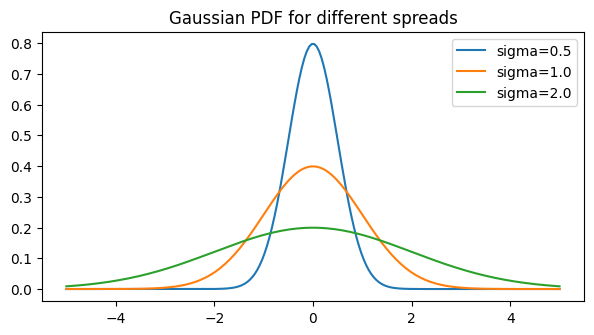

In [19]:
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson mean ~ 1.971
True mean = 2


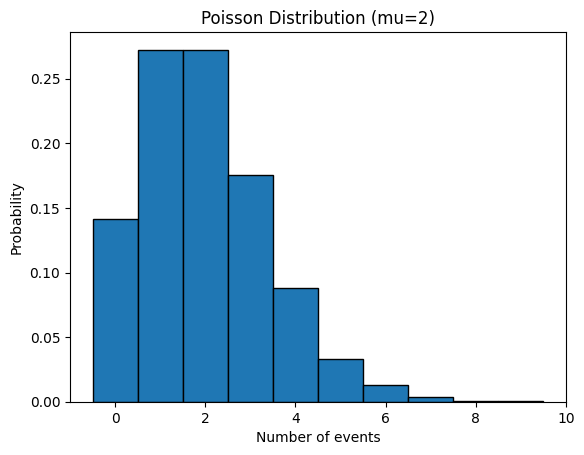

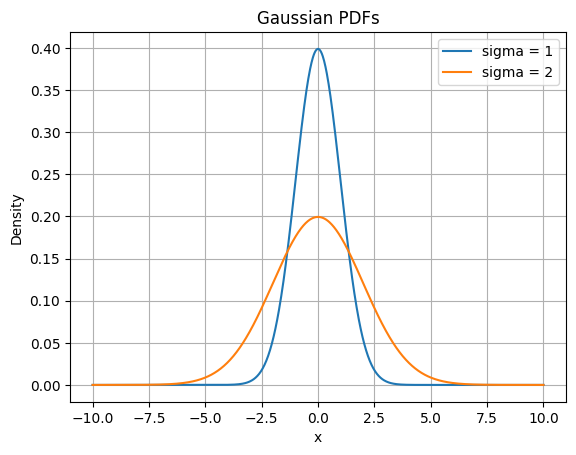

In [21]:
#lab exercise-4
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Poisson(mu=2) samples + mean
pois = stats.poisson(mu=2).rvs(size=10_000)

print("Poisson mean ~", round(pois.mean(), 3))
print("True mean =", 2)

# 2. Histogram of the samples
plt.hist(pois, bins=np.arange(-0.5, pois.max() + 1.5, 1),
         density=True, edgecolor="black")

plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.title("Poisson Distribution (mu=2)")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-10, 10, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = stats.norm.pdf(x, loc=mu, scale=sigma1)
pdf2 = stats.norm.pdf(x, loc=mu, scale=sigma2)

plt.plot(x, pdf1, label="sigma = 1")
plt.plot(x, pdf2, label="sigma = 2")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian PDFs")
plt.legend()
plt.grid()
plt.show()


In [22]:
# 🔹 5A. ENTROPY — how uncertain is a distribution?
from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [23]:
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [24]:
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [25]:
#lab exercise-5
import numpy as np
from scipy.stats import entropy

# 1. Entropy of a fair 4-sided and 6-sided die (base=2)
p4 = [1/4] * 4
p6 = [1/6] * 6

H4 = entropy(p4, base=2)
H6 = entropy(p6, base=2)

print("Entropy of 4-sided die =", round(H4, 3), "bits")
print("Entropy of 6-sided die =", round(H6, 3), "bits")


# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

KL = entropy(P, Q, base=2)

print("KL divergence D(P || Q) =", round(KL, 3), "bits")


# 3. Most / least informative iris feature (from 5C)
# Based on typical Iris classification performance:
# Most informative: petal length
# Least informative: sepal width

print("Most informative: petal length")
print("Least informative: sepal width")


Entropy of 4-sided die = 2.0 bits
Entropy of 6-sided die = 2.585 bits
KL divergence D(P || Q) = 0.119 bits
Most informative: petal length
Least informative: sepal width
